## Extract isolated beads

This notebook is used to extract isolated beads to be used for calibration.   

Some beads may be too near other beads or biological material to be useful for calibration.  So extracting the beads is a 2 part process.

1.  Detect all beads using local max
2.  Crop beads and run a local contrast test to detect isolated beads with a strong signal.
3.  Only keep beads that are well centered laterally and axially. 
4.  Save the good beads so they can be used for calibration.  

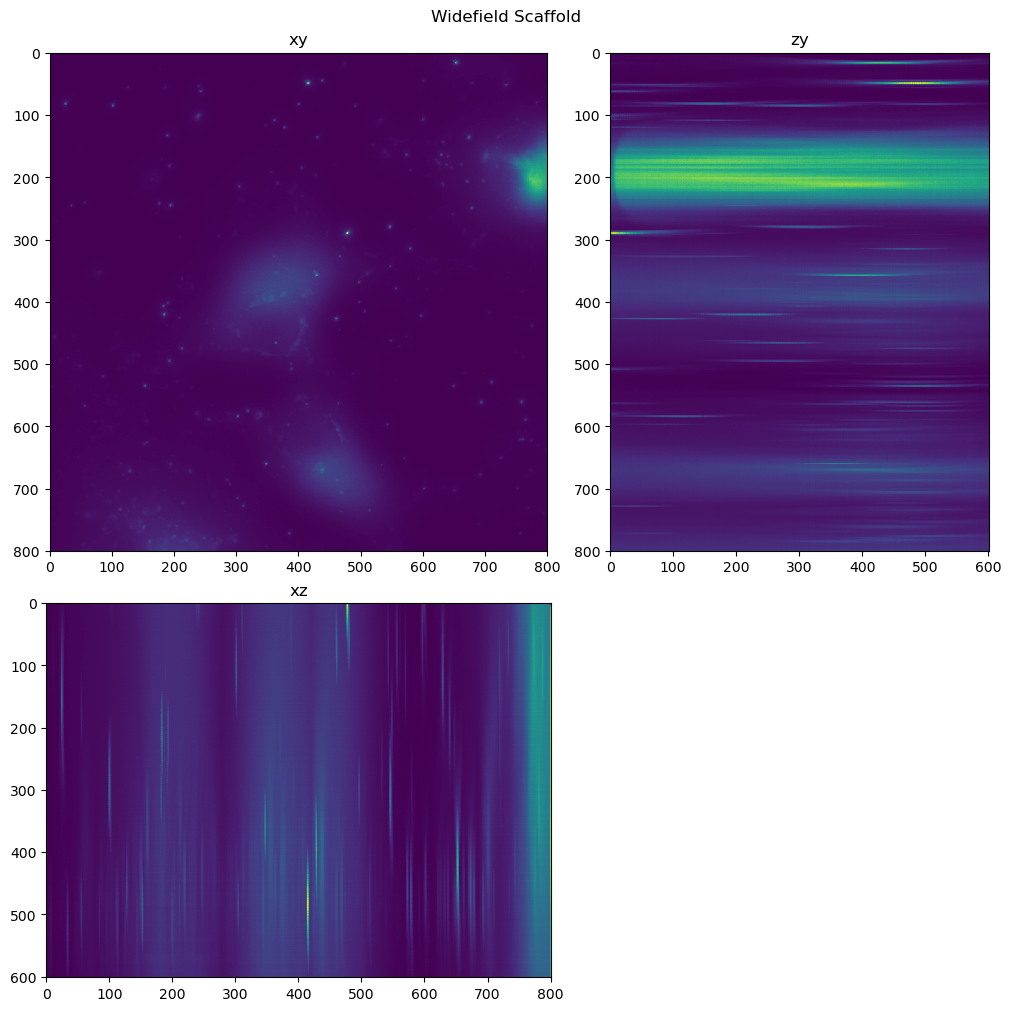

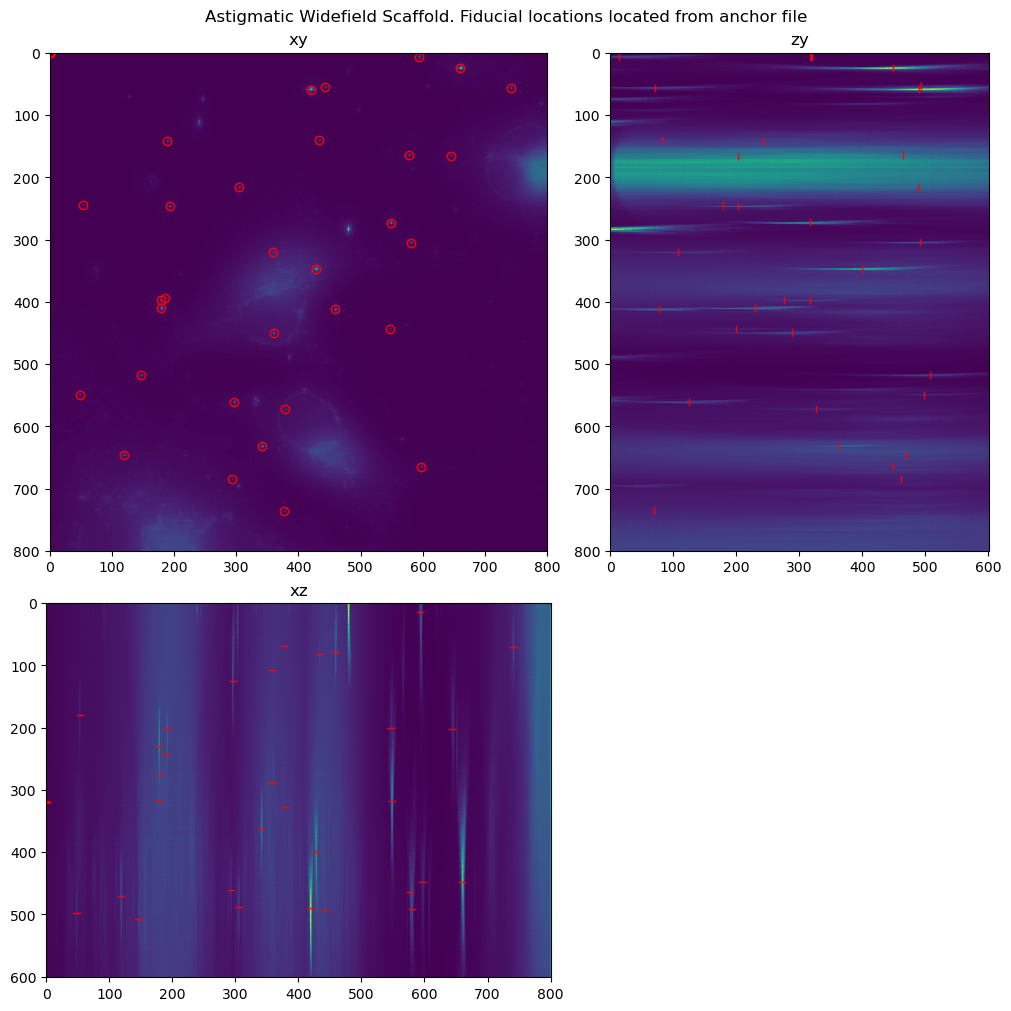

In [1]:
import matplotlib.pyplot as plt
from matplotlib import axes
from skimage.io import imread, imsave
import napari
from scipy.ndimage import gaussian_filter
import os
import pandas as pd
from tnia.plotting.projections import show_xyz_max, show_xyz_projection_peaks
import numpy as np

calib_path = r'D:\Janelia_slm_data\calibrations'
experiment_name = 'Janelia PALM RUN2'
calib_path = os.path.join(calib_path, experiment_name)

calib_crop_path = os.path.join(calib_path, 'crops')

if not os.path.exists(calib_crop_path):
    os.makedirs(calib_crop_path)

filename_widefield = os.path.join(calib_path, '3a - Widefield_Scaffold_Z-Stack_488nm_and_532nm_RAW_TIFF_IMAGE.tif')
filename_astigmatic = os.path.join(calib_path, '1a - Astigmatic_Widefield_scaffold_Z-Stack_RAW_TIFF_IMAGE.tif')

img_widefield = imread(filename_widefield)
img_astigmatic = imread(filename_astigmatic)

fig = show_xyz_max(img_widefield, sxy = 1, sz=1)
fig.suptitle('Widefield Scaffold')

fig = show_xyz_max(img_astigmatic, sxy = 1, sz=1)
fig.suptitle('Astigmatic Widefield Scaffold. Fiducial locations located from anchor file')

axes = fig.axes

points_name = os.path.join(calib_path, '1c - Astigmatic_Widefield_scaffold_Z-Stack_RAW_PALM_LOCALIZATION_DATA_31_beads_selected_fiducial_locations_in_XY_ANCHOR_FILE.anc')
# read the anchor file in fwf format
df = pd.read_fwf(points_name, header=None, usecols=[1, 0], names=['x', 'y'])

show_xyz_projection_peaks(img_astigmatic, df['x'], df['y'], fig.axes[0], fig.axes[1], fig.axes[2])


(39, 2)


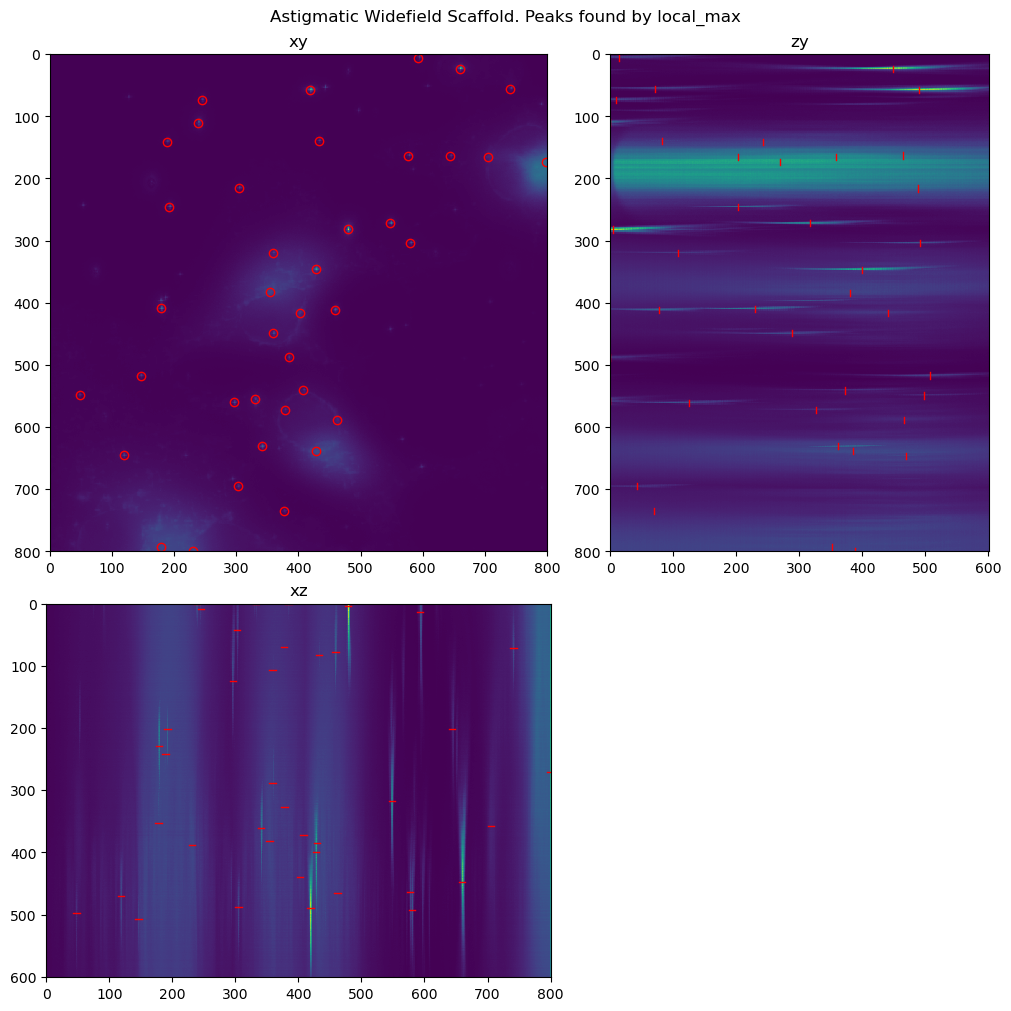

In [2]:
from skimage.feature import peak_local_max
from tnia.plotting.projections import show_xyz_projection_peaks

img_smoothed = img_astigmatic.max(axis=0)
img_smoothed = gaussian_filter(img_smoothed, sigma=1)

peaks = peak_local_max(img_smoothed, min_distance=25, threshold_abs=img_astigmatic.max()/10, exclude_border=False)

print(peaks.shape)

fig = show_xyz_max(img_astigmatic)
fig.suptitle('Astigmatic Widefield Scaffold. Peaks found by local_max')

show_xyz_projection_peaks(img_astigmatic, peaks[:,1], peaks[:,0], fig.axes[0], fig.axes[1], fig.axes[2])

#show_xyz_projection_peaks(img_astigmatic, good_points[:,1], good_points[:,0], fig.axes[0], fig.axes[1], fig.axes[2], marker='x', color='cyan')


In [3]:
viewer = napari.Viewer()
viewer.add_image(img_widefield, name='widefield image', colormap='gray')
viewer.add_image(img_astigmatic, name='calibration image', colormap='gray')
viewer.add_points(df[['y', 'x']].values, name='calibration points', size=10, face_color='red')

<Points layer 'calibration points' at 0x2b5df5f5640>

In [4]:
len(peaks)

39

Contrast score for point (282, 479): 17.436054014298325


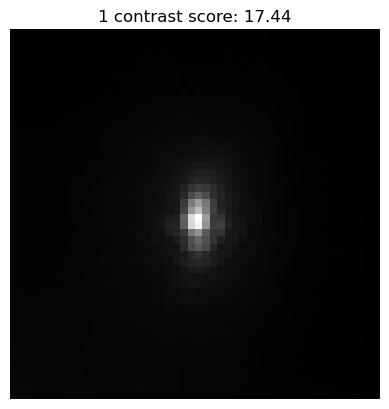

Contrast score for point (58, 419): 23.220520398952445


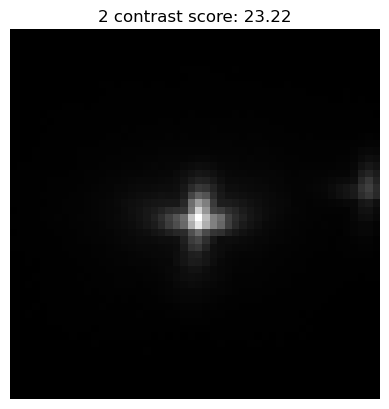

Contrast score for point (346, 428): 5.980877665083961
there are 1 bad points


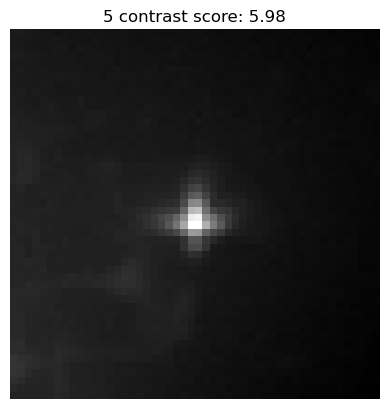

Contrast score for point (272, 548): 21.154225436641397


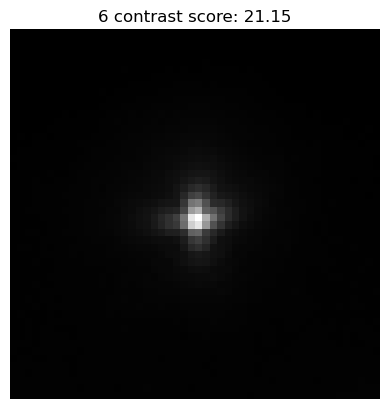

Contrast score for point (409, 179): 11.696431035509534


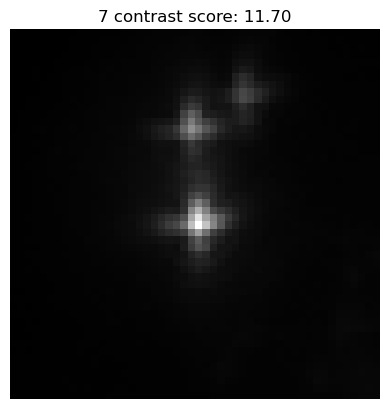

Contrast score for point (631, 341): 13.189132272229191


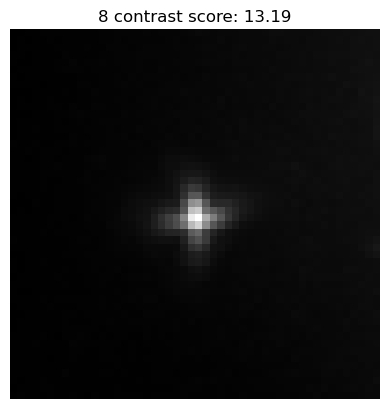

Contrast score for point (411, 459): 15.158917658237415


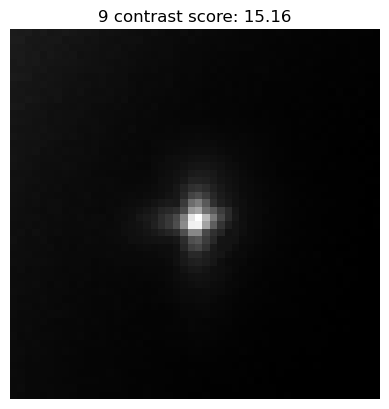

Contrast score for point (110, 239): 11.123209839625034


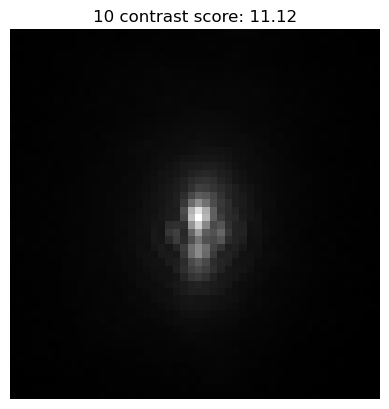

Contrast score for point (639, 428): 1.3669133285748
there are 2 bad points


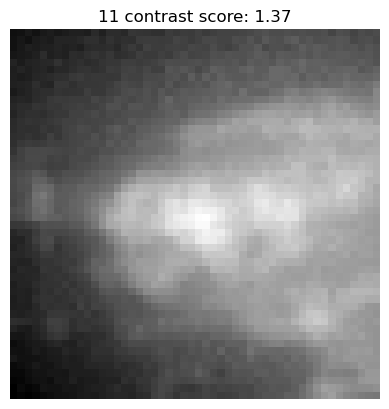

Contrast score for point (246, 192): 18.46224599574595


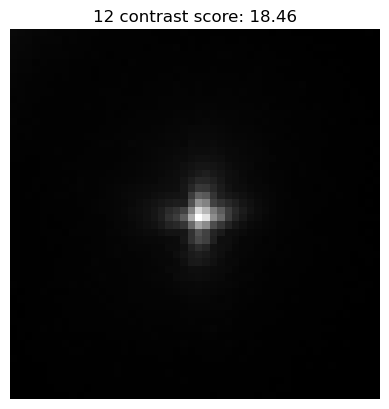

Contrast score for point (383, 354): 1.3072839973172115
there are 3 bad points


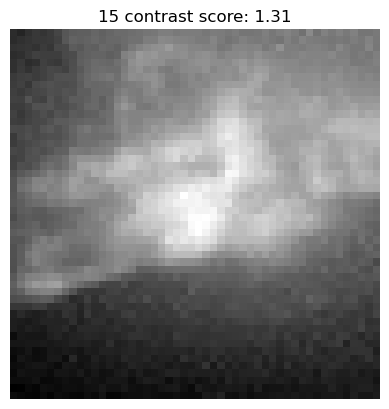

Contrast score for point (560, 296): 9.917544184250536
there are 4 bad points


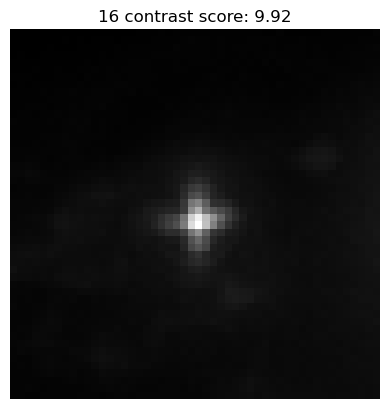

Contrast score for point (449, 359): 4.233753255509126
there are 5 bad points


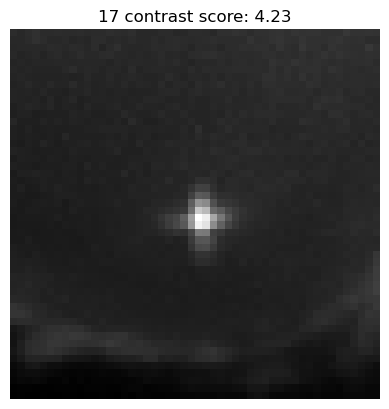

Contrast score for point (304, 580): 16.293657526347726


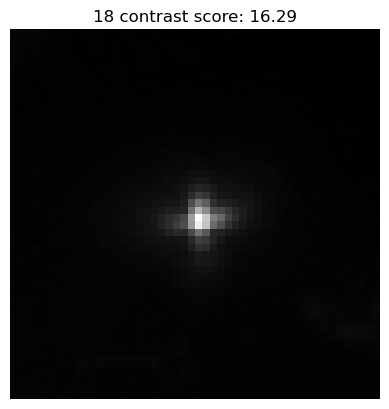

Contrast score for point (645, 119): 6.061416662166821
there are 6 bad points


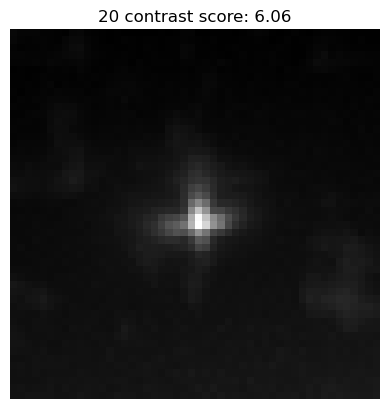

Contrast score for point (56, 741): 12.970294124707594


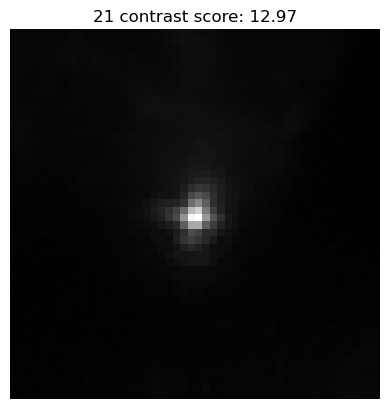

Contrast score for point (215, 305): 13.221946119771971


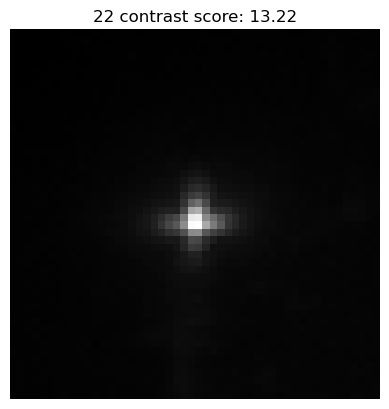

Contrast score for point (141, 189): 17.591554139936896


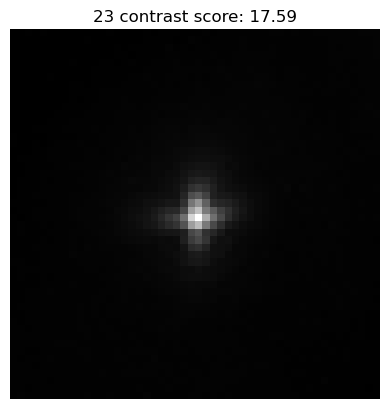

Contrast score for point (416, 402): 2.078443257704808
there are 7 bad points


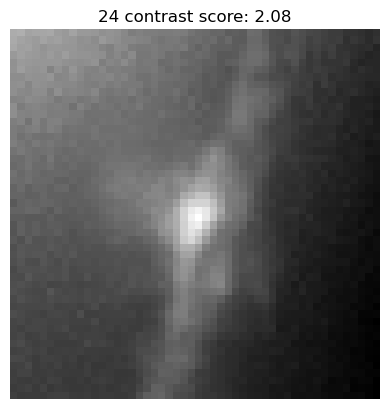

Contrast score for point (517, 146): 12.439881343156562


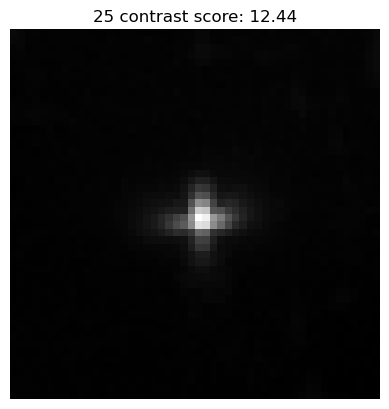

Contrast score for point (555, 330): 4.668897533827592
there are 8 bad points


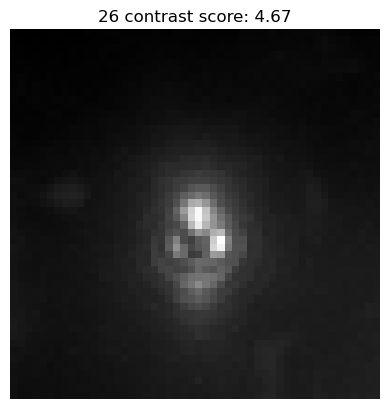

Contrast score for point (74, 245): 15.28645526977167


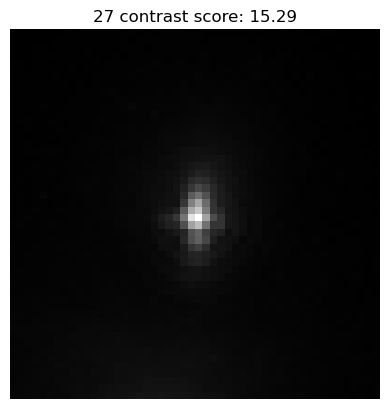

Contrast score for point (163, 577): 12.95301420676777


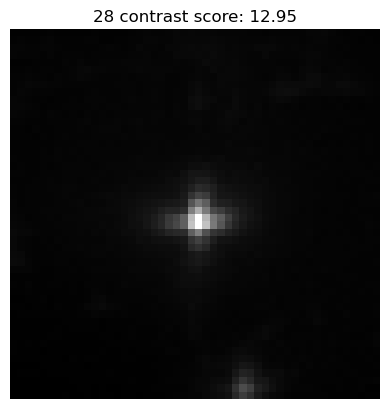

Contrast score for point (320, 359): 2.4795946490279634
there are 9 bad points


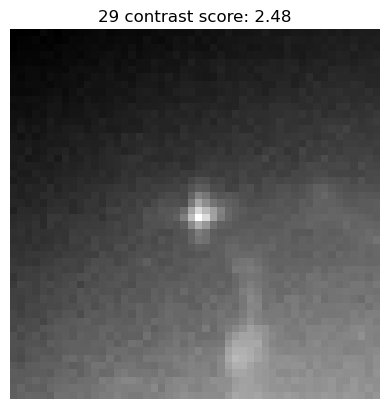

Contrast score for point (695, 303): 6.746571885106368
there are 10 bad points


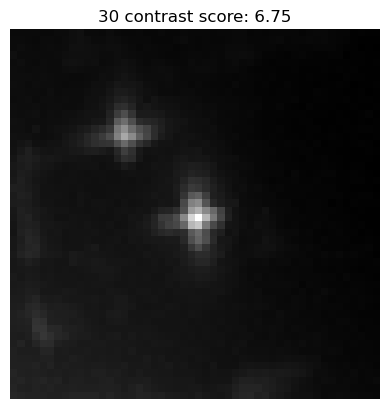

Contrast score for point (488, 384): 7.818509855264523
there are 11 bad points


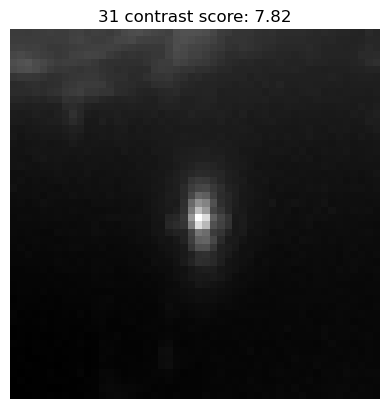

Contrast score for point (140, 433): 15.86294978666484


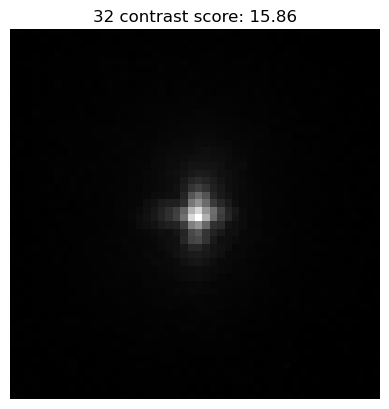

Contrast score for point (588, 462): 2.0477047200965925
there are 12 bad points


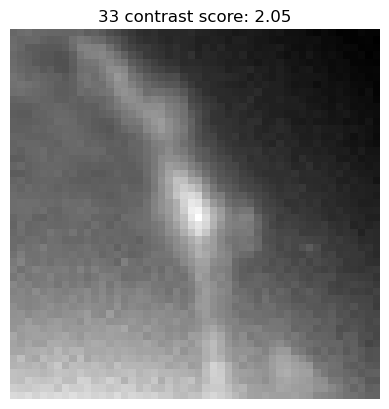

Contrast score for point (540, 408): 3.715551288485457
there are 13 bad points


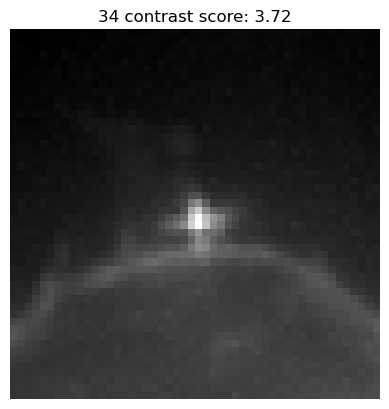

Contrast score for point (572, 378): 3.0746207951475926
there are 14 bad points


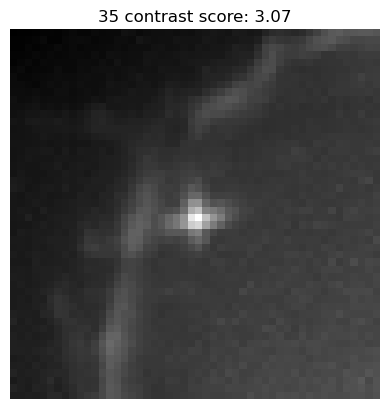

Contrast score for point (164, 644): 7.154182537744423
there are 15 bad points


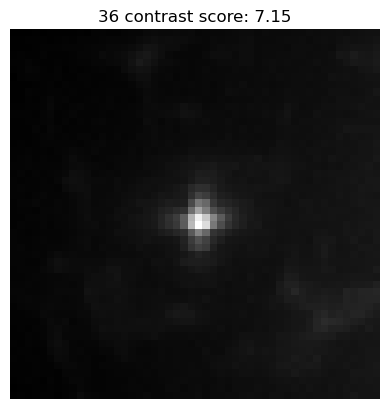

Contrast score for point (166, 705): 1.6937939607130788
there are 16 bad points


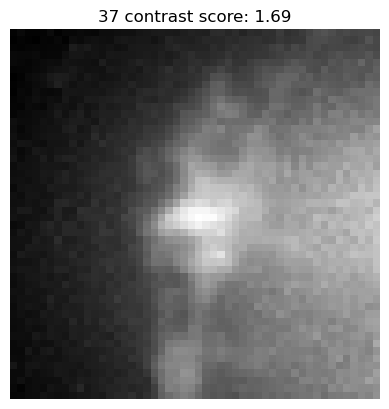

Contrast score for point (735, 377): 8.640658317566146
there are 17 bad points


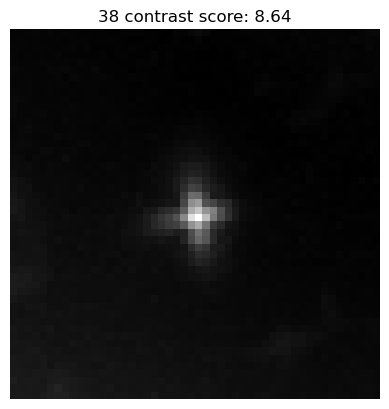

Contrast score for point (548, 48): 7.390485768762216
there are 18 bad points


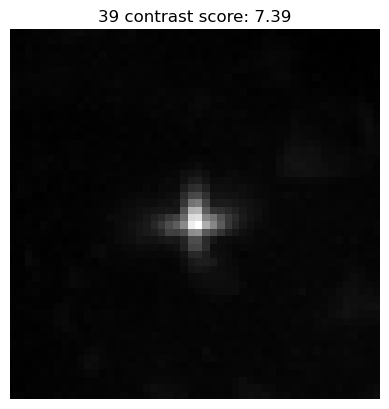

In [4]:
z_half_crop = 300
y_half_crop = 25
x_half_crop = 25

good_crops = []
bad_crops = []

good_points = []
bad_points = []

img = img_astigmatic

def local_contrast_score(image, y, x, inner=3, outer=15):
    y0, y1 = y-outer, y+outer+1
    x0, x1 = x-outer, x+outer+1
    patch = image[y0:y1, x0:x1]

    # Create circular mask for ring
    Y, X = np.ogrid[-outer:outer+1, -outer:outer+1]
    dist = np.sqrt(X**2 + Y**2)
    ring_mask = (dist <= outer) & (dist > inner)

    ring_values = patch[ring_mask]
    background_mean = np.mean(ring_values)

    return image[y, x]/background_mean

# crop the image around the good points
for i, point in enumerate(peaks): #good_points:
    #y, x = point
    y,x=point
    cropped_img = img[
        img.shape[0] // 2 - z_half_crop:img.shape[0] // 2 + z_half_crop,
        y - y_half_crop:y + y_half_crop,
        x - x_half_crop:x + x_half_crop,
        
    ]

    if cropped_img.shape[0] > 400 and cropped_img.shape[1] > (y_half_crop*2-1) and cropped_img.shape[2] > (x_half_crop*2-1):
        max_cropped_img = cropped_img.max(axis=0)
        contrast_score = local_contrast_score(max_cropped_img, y_half_crop, x_half_crop)
        
        print(f'Contrast score for point ({y}, {x}): {contrast_score}')
        
        if contrast_score > 10:
            good_crops.append(cropped_img)
            good_points.append(point)
        else:
            bad_crops.append(cropped_img)
            bad_points.append(point)
            print(f'there are {len(bad_points)} bad points')

        plt.figure()
        plt.imshow(cropped_img.max(axis=0), cmap='gray')
        plt.title(f'{i + 1} contrast score: {contrast_score:.2f}')
        plt.axis('off')
        plt.show()


In [5]:
len(good_crops), len(good_points)

(16, 16)

Processing cropped image 1 with point [282 479]
Location of maximum value: (0, 26, 25)
Maximum value: 6074
(0, 49, 50)
there are 19 bad points
Processing cropped image 2 with point [ 58 419]
Location of maximum value: (484, 26, 25)
Maximum value: 4834
(316, 49, 50)
there are 20 bad points
Processing cropped image 3 with point [272 548]
Location of maximum value: (313, 25, 25)
Maximum value: 2286
(400, 50, 50)


C:\Users\bnort\AppData\Local\Temp\ipykernel_9932\1847988532.py:43: UserWarning: D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\Janelia PALM RUN2_2.tif is a low contrast image
  imsave(os.path.join(calib_crop_path, f'{experiment_name}_{i}.tif'), cropped)


Processing cropped image 4 with point [409 179]
Location of maximum value: (235, 26, 25)
Maximum value: 2440
(400, 49, 50)
there are 21 bad points
Processing cropped image 5 with point [631 341]
Location of maximum value: (375, 25, 25)
Maximum value: 2384
(400, 50, 50)


C:\Users\bnort\AppData\Local\Temp\ipykernel_9932\1847988532.py:43: UserWarning: D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\Janelia PALM RUN2_4.tif is a low contrast image
  imsave(os.path.join(calib_crop_path, f'{experiment_name}_{i}.tif'), cropped)


Processing cropped image 6 with point [411 459]
Location of maximum value: (79, 26, 25)
Maximum value: 2200
(0, 49, 50)
there are 22 bad points
Processing cropped image 7 with point [110 239]
Location of maximum value: (0, 26, 25)
Maximum value: 2716
(0, 49, 50)
there are 23 bad points
Processing cropped image 8 with point [246 192]
Location of maximum value: (209, 25, 25)
Maximum value: 1831
(400, 50, 50)


C:\Users\bnort\AppData\Local\Temp\ipykernel_9932\1847988532.py:43: UserWarning: D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\Janelia PALM RUN2_7.tif is a low contrast image
  imsave(os.path.join(calib_crop_path, f'{experiment_name}_{i}.tif'), cropped)


Processing cropped image 9 with point [304 580]
Location of maximum value: (489, 26, 25)
Maximum value: 1378
(311, 49, 50)
there are 24 bad points
Processing cropped image 10 with point [ 56 741]
Location of maximum value: (72, 25, 24)
Maximum value: 1407
(0, 50, 0)
there are 25 bad points
Processing cropped image 11 with point [215 305]
Location of maximum value: (493, 26, 24)
Maximum value: 1291
(307, 49, 0)
there are 26 bad points
Processing cropped image 12 with point [141 189]
Location of maximum value: (252, 25, 25)
Maximum value: 1263
(400, 50, 50)


C:\Users\bnort\AppData\Local\Temp\ipykernel_9932\1847988532.py:43: UserWarning: D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\Janelia PALM RUN2_11.tif is a low contrast image
  imsave(os.path.join(calib_crop_path, f'{experiment_name}_{i}.tif'), cropped)


Processing cropped image 13 with point [517 146]
Location of maximum value: (489, 26, 25)
Maximum value: 1239
(311, 49, 50)
there are 27 bad points
Processing cropped image 14 with point [ 74 245]
Location of maximum value: (9, 25, 25)
Maximum value: 1227
(0, 50, 50)
there are 28 bad points
Processing cropped image 15 with point [163 577]
Location of maximum value: (461, 26, 25)
Maximum value: 1176
(339, 49, 50)
there are 29 bad points
Processing cropped image 16 with point [140 433]
Location of maximum value: (93, 25, 25)
Maximum value: 1052
(0, 50, 50)
there are 30 bad points


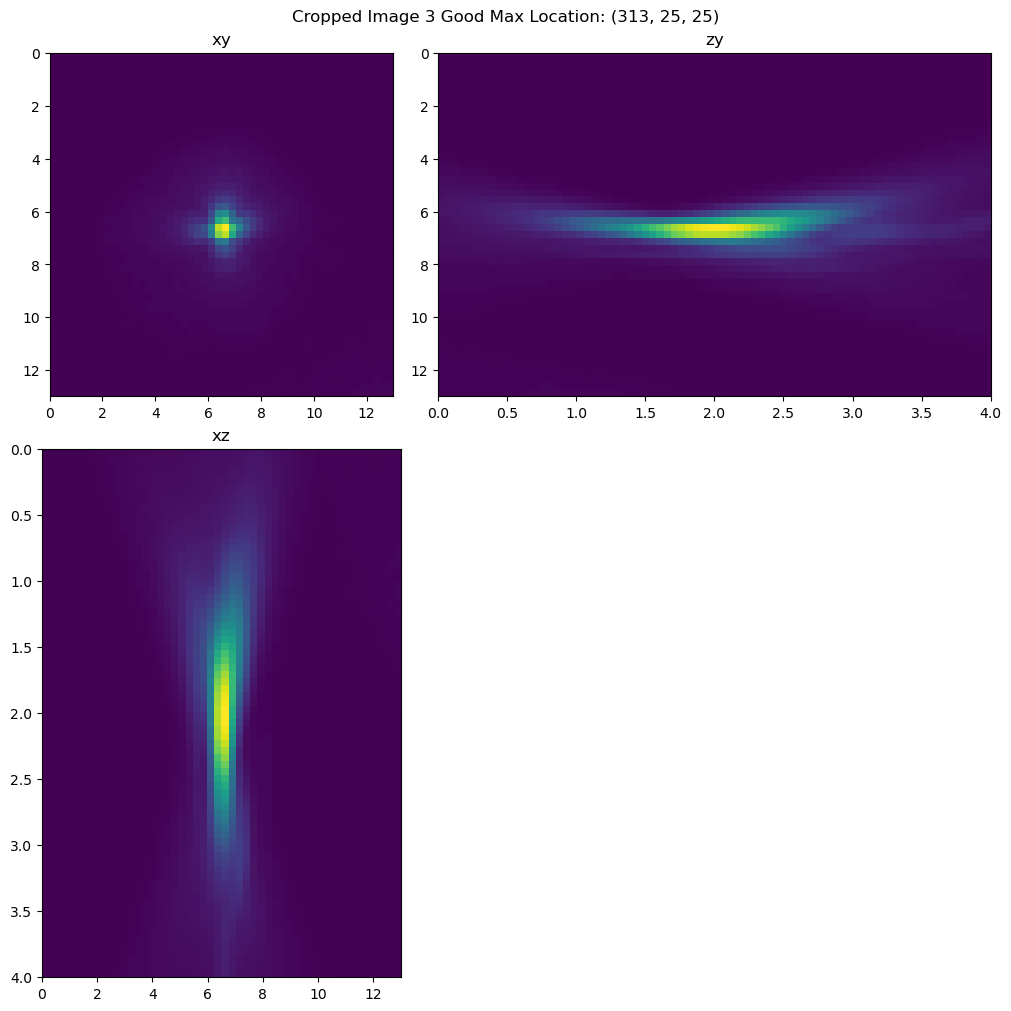

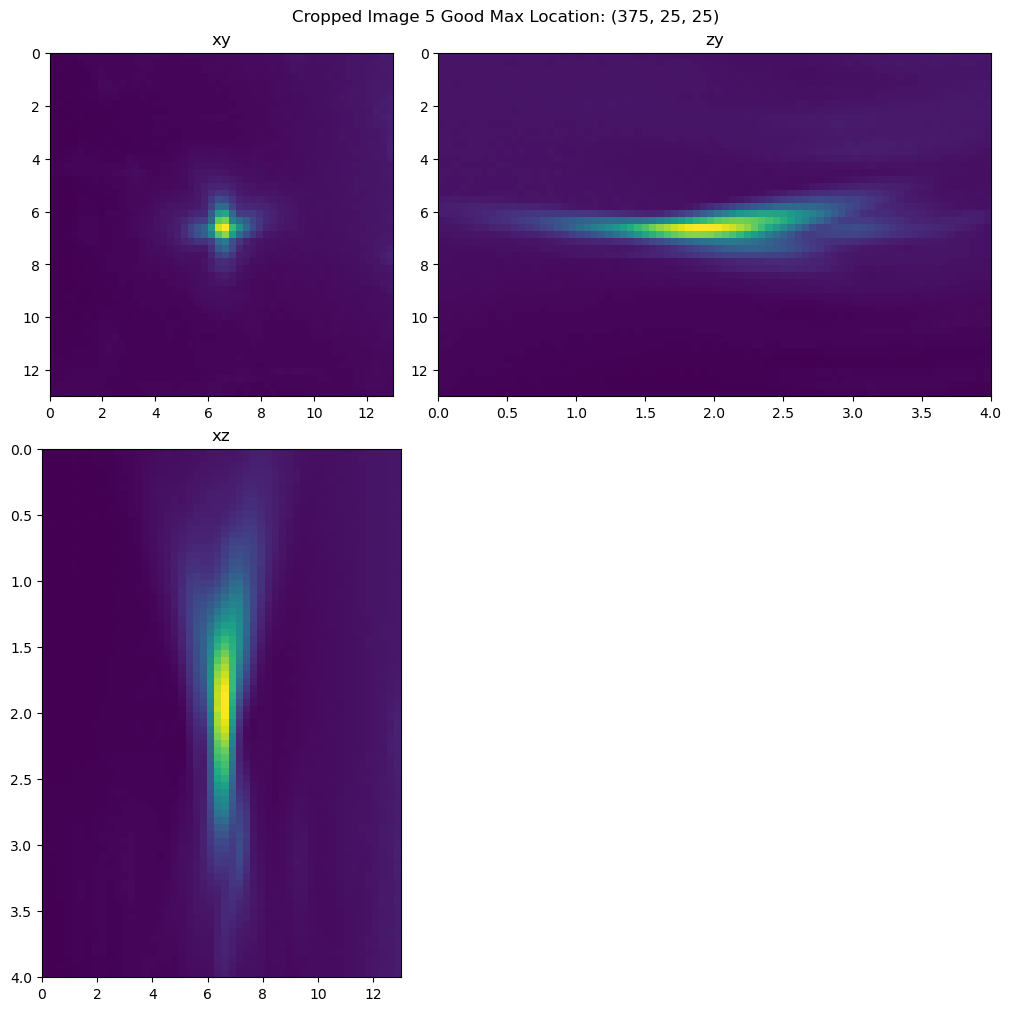

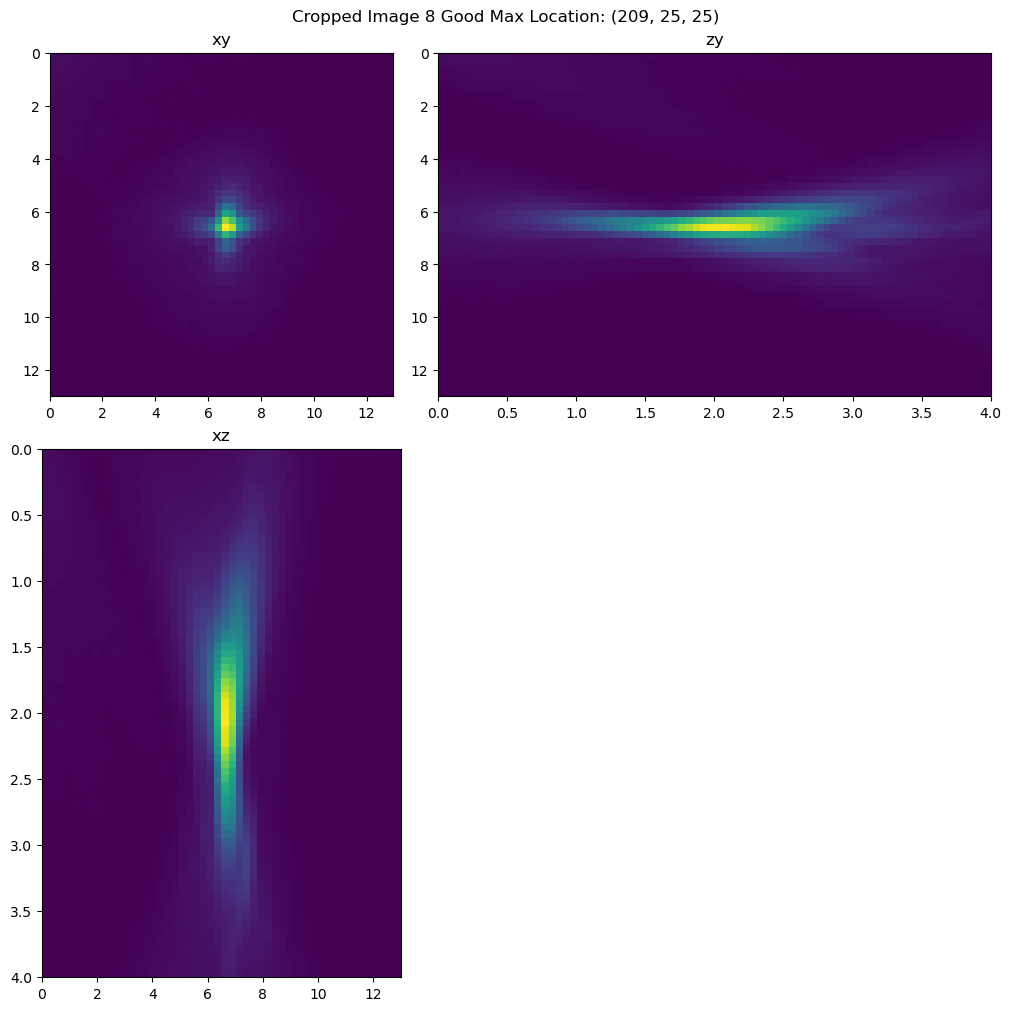

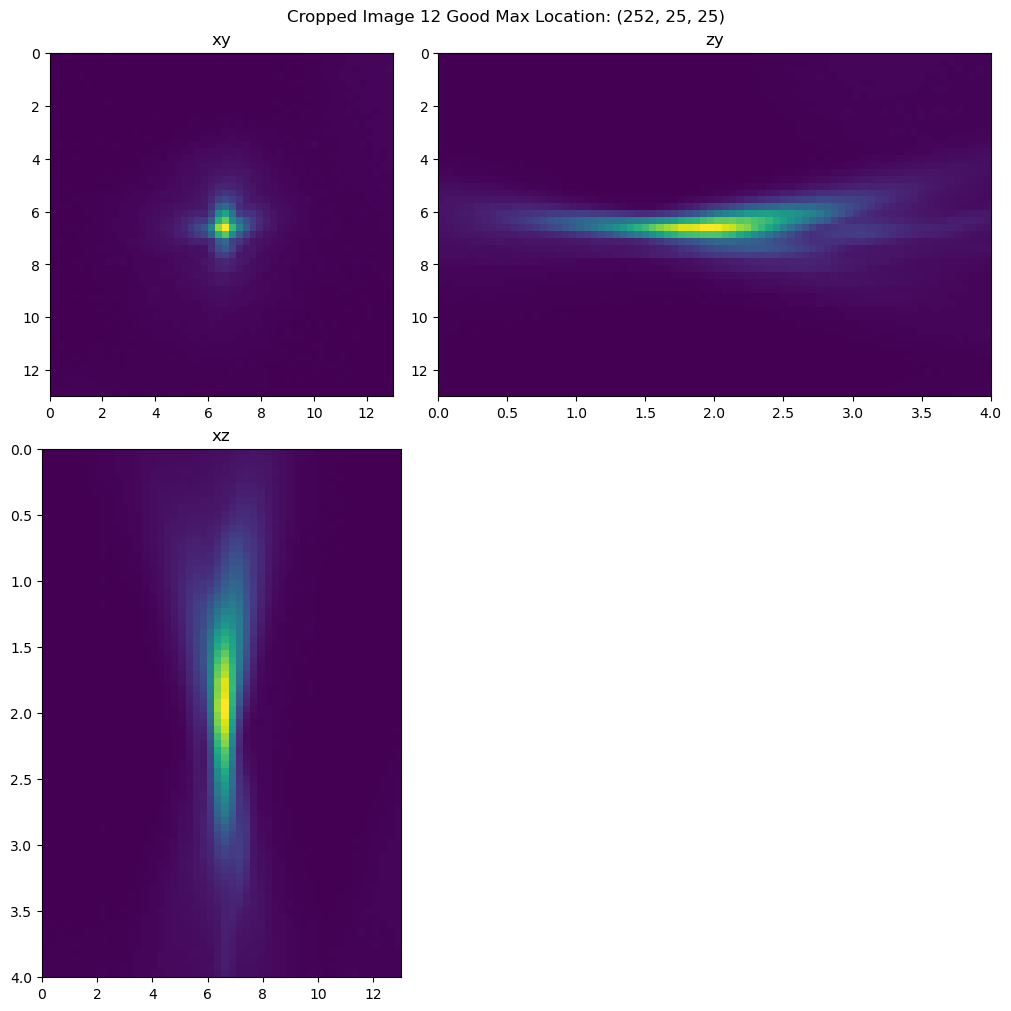

In [6]:

from scipy.ndimage import gaussian_filter

final_good_points = []

for i, (cropped_img, point)  in enumerate(zip(good_crops, good_points)):
    print(f'Processing cropped image {i + 1} with point {point}')

    # Plotting
    #fig = show_xyz_max(cropped_img, sxy=1, sz=1)

    sigma = 3
    smoothed_cropped_img = gaussian_filter(cropped_img, sigma=sigma)

    max_location = np.unravel_index(np.argmax(smoothed_cropped_img, axis=None), smoothed_cropped_img.shape)

    print(f"Location of maximum value: {max_location}")
    print(f"Maximum value: {smoothed_cropped_img[max_location]}")

    z_half_crop = 200
    y_half_crop = 25
    x_half_crop = 25

    cropped = cropped_img[max_location[0]-z_half_crop:max_location[0]+z_half_crop,
                            max_location[1]-y_half_crop:max_location[1]+y_half_crop,
                            max_location[2]-x_half_crop:max_location[2]+x_half_crop]
    
    print(cropped.shape)

    good_point = False    
    if cropped.shape[0] > (z_half_crop*2-1) and cropped.shape[1] > (y_half_crop*2-1) and cropped.shape[2] > (x_half_crop*2-1):
        final_good_points.append(point)
        good_point = True
    
        zdim = cropped.shape[0]
        ydim = cropped.shape[1]
        xdim = cropped.shape[2]
        
        # Plotting
        fig = show_xyz_max(cropped, sxy=.26, sz=.05, extentzy=[0,zdim*0.01,ydim*.26,0], extentxz=[0,xdim*.26, zdim*0.01, 0]) 
        #fig = show_xyz_max(cropped, sxy=.26, sz=.05)
        fig.suptitle(f'Cropped Image {i + 1} {"Good" if good_point else "Bad"} Max Location: {max_location}')
        fig.savefig(os.path.join(calib_crop_path, f'{experiment_name}_{i}.png'))
        imsave(os.path.join(calib_crop_path, f'{experiment_name}_{i}.tif'), cropped)
        
    else:
        bad_points.append(point)
        print(f'there are {len(bad_points)} bad points')


    

In [9]:
len(good_points), len(bad_points)

(16, 30)

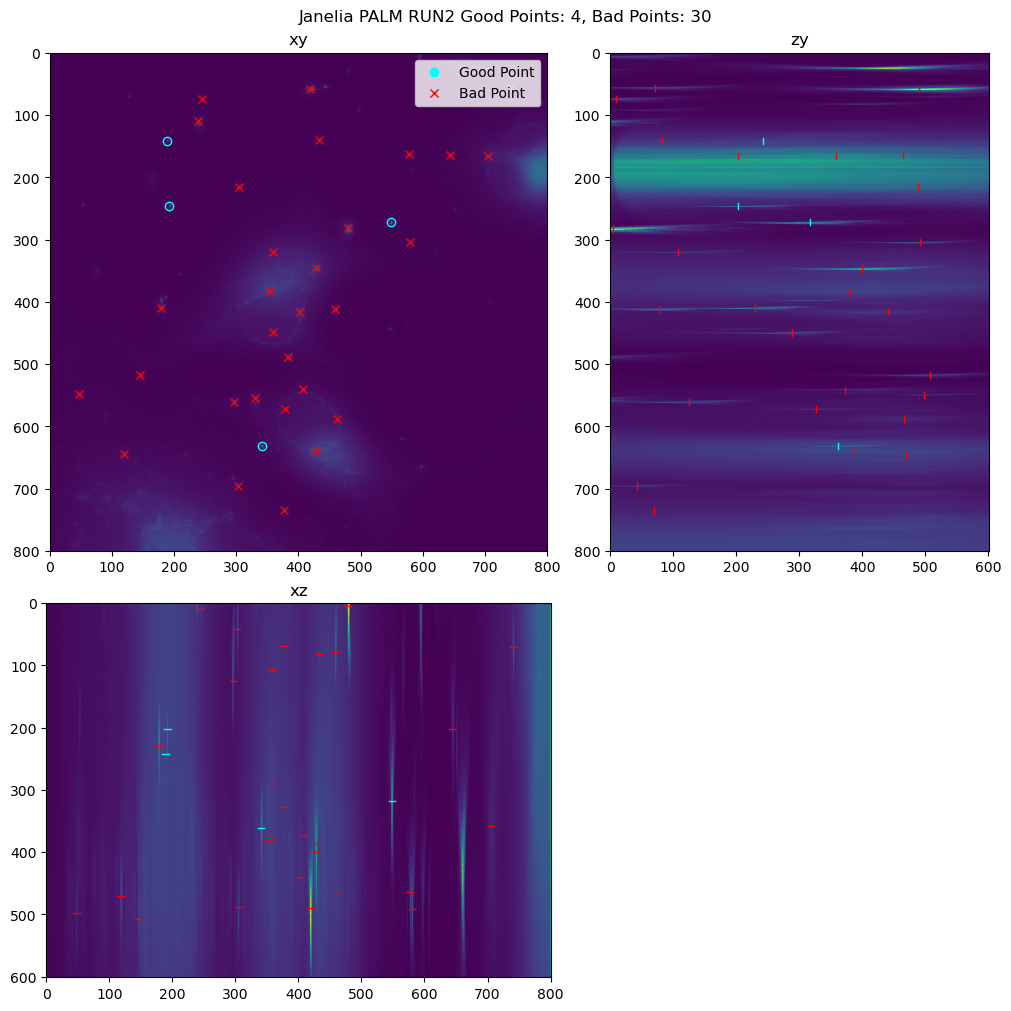

In [10]:
from matplotlib import lines as mlines

fig = show_xyz_max(img_astigmatic)
show_xyz_projection_peaks(img_astigmatic, np.array(final_good_points)[:,1], np.array(final_good_points)[:,0], fig.axes[0], fig.axes[1], fig.axes[2], marker='o', color='cyan')
show_xyz_projection_peaks(img_astigmatic, np.array(bad_points)[:,1], np.array(bad_points)[:,0], fig.axes[0], fig.axes[1], fig.axes[2], marker='x', color='red')

# Create legend handles (dummy artists)
good_handle = mlines.Line2D([], [], color='cyan', marker='o', linestyle='None', label='Good Point')
bad_handle  = mlines.Line2D([], [], color='red',  marker='x', linestyle='None', label='Bad Point')

# Add legend to main axis (e.g., ax_xy)
fig.axes[0].legend(handles=[good_handle, bad_handle], loc='upper right')  # or 'lower left', etc.
fig.suptitle(f'{experiment_name} Good Points: {len(final_good_points)}, Bad Points: {len(bad_points)}')
fig.savefig(os.path.join(calib_crop_path, f'{experiment_name}_final_points.png'))